In [4]:
import numpy as np
import matplotlib.pyplot as plt
from functions import *
from cluster import *
from core import *
from ode_methods import *
from utils import *

In [2]:
### --- PUT ALL TOGETHER --- ###

n = 400
W = np.random.normal(0, 1/np.sqrt(n), (n, n))

rnn = Time_Cts_RNN(W, tanh, g=1.2)
ode_method = Euler(0.001)
sim = Simulation(rnn)
x_init = np.random.normal(0, 1/np.sqrt(n), n)
sim.run(T=1000, ode_method=ode_method, x_init=x_init, monitors=['rnn.x'])

Progress: 10.0% complete 
Time Elapsed: 2.5s 

Progress: 20.0% complete 
Time Elapsed: 5.1s 

Progress: 30.0% complete 
Time Elapsed: 7.7s 

Progress: 40.0% complete 
Time Elapsed: 10.3s 

Progress: 50.0% complete 
Time Elapsed: 13.0s 

Progress: 60.0% complete 
Time Elapsed: 15.6s 

Progress: 70.0% complete 
Time Elapsed: 18.1s 

Progress: 80.0% complete 
Time Elapsed: 20.6s 

Progress: 90.0% complete 
Time Elapsed: 23.1s 



(-0.3, 0.3)

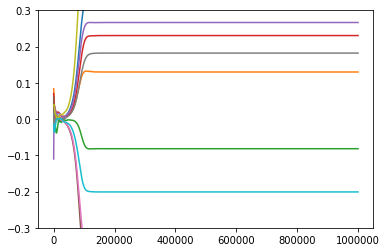

In [3]:
fig = plt.figure()
for i in range(10):
    plt.plot(sim.mons['rnn.x'][:,i])
plt.ylim([-0.3, 0.3])

In [11]:
### --- FUNCTIONS --- ###

class Function:
    """Defines a function and its derivative.

    Attributes:
        f (function): An element-wise differentiable function that acts on a
            1-d numpy array of arbitrary dimension. May include a second
            argument for a label, e.g. for softmax-cross-entropy.
        f_prime (function): The element-wise derivative of f with respect to
            the first argument, must also act on 1-d numpy arrays of arbitrary
            dimension."""

    def __init__(self, f, f_prime):
        """Inits an instance of Function by specifying f and f_prime."""

        self.f = f
        self.f_prime = f_prime
        
### --- Define tanh --- ###

def tanh_(z):

    return np.tanh(z)

def tanh_derivative(z):

    return 1 - np.tanh(z) ** 2

tanh = Function(tanh_, tanh_derivative)

In [38]:
### --- UTILS --- ###
import itertools
from functools import reduce

def get_spectral_radius(M):
    """Calculates the spectral radius of a matrix."""

    eigs, _ = np.linalg.eig(M)

    return np.amax(np.absolute(eigs))

def norm(z):
    """Computes the L2 norm of a numpy array."""

    return np.sqrt(np.sum(np.square(z)))

def rgetattr(obj, attr):
    """A "recursive" version of getattr that can handle nested objects.

    Args:
        obj (object): Parent object
        attr (string): Address of desired attribute with '.' between child
            objects.
    Returns:
        The attribute of obj referred to."""

    return reduce(getattr, [obj] + attr.split('.'))

In [39]:
### --- NETWORK --- ###

class Time_Cts_RNN:
    """Class for time continuous vanilla RNN"""
    
    def __init__(self, W, activation, g=1):
        """Initialize with parameters, activation function, gain."""
        
        if W.shape[0] != W.shape[1]:
            raise ValueError('W must be a square matrix')
        
        self.W = W
        self.activation = activation
        self.g = g
        
        self.n = self.W.shape[0]
        self.x = np.zeros(self.n)
        self.phi = self.activation.f(self.x)
        
    def x_dot(self, I=None):
        """Return time derivative in terms of current network
        state and an external input, if provided. Also updates
        the internal value of eta."""
        
        self.eta = self.W.dot(self.activation.f(self.x))
        ret = -self.x + self.eta
        if I is not None:
            self.I = I
            ret += self.I
        return ret

In [40]:
### --- ODE METHODS --- ###

class ODE_Method:
    """Parent class for all ODE methods"""
    
    def __init__(self, dt):
        """Initialize any ODE method with its core time
        discretization"""
        
        self.dt = dt
        
    def next_state(self, state, state_derviative):
        """Each method fills in its own method for getting
        the next discrete state in terms of the current state"""
        
        pass
        
class Euler(ODE_Method):
    """Simplest ODE method, forward standard Euler"""
    
    def __init__(self, dt):
        """Initialize with just the core time discretization"""
        
        super().__init__(dt)
    
    def next_state(self, state, state_derivative):
        """Update next state as sum of previous plus derivative
        scaled by dt"""
        
        return state + self.dt * state_derivative

In [50]:
### --- SIMULATION --- ###
import time

class Simulation:
    """Simulation class"""
    
    def __init__(self, rnn):
        """Initialize with the rnn under study"""
        
        self.rnn = rnn
        
    def run(self, T, ode_method, x_init, monitors=[], I_ext=None,
            verbose=True):
        
        #Store core attributes
        self.T = T
        self.ode_method = ode_method
        self.x_init = x_init
        self.rnn.x = x_init.copy()
        self.rnn.phi = self.rnn.activation.f(self.rnn.x)
        self.time_vector = np.arange(0, T, ode_method.dt)
        self.total_time_steps = len(self.time_vector)
        self.report_interval = max(self.total_time_steps // 10, 1)
        self.verbose = verbose
        
        #Initialize monitors
        self.mons = {k: [] for k in monitors}
        
        #Initialize start time
        self.start_time = time.time()
        
        for i_t, t in enumerate(self.time_vector):
            
            self.i_t = i_t
            self.t = t
            
            #Check for external input
            if I_ext is not None:
                I = I_ext[i_t]
            else:
                I = None
                
            #Update network state
            self.rnn.x = self.ode_method.next_state(self.rnn.x, self.rnn.x_dot(I=I))
            
            #Update monitors
            self.update_monitors()
            self.get_radii_and_norms()
            
            #Make report if conditions are met
            if (self.i_t % self.report_interval == 0 and
                self.i_t > 0 and
                self.verbose):
                self.report_progress()
        
        self.monitors_to_arrays()
                
    def report_progress(self):
        """"Reports progress at specified interval, including test run
        performance if specified."""

        progress = np.round((self.i_t/self.total_time_steps)*100, 2)
        time_elapsed = np.round(time.time() - self.start_time, 1)

        summary = '\rProgress: {}% complete \nTime Elapsed: {}s \n'
        print(summary.format(progress, time_elapsed))
    
    def update_monitors(self):
        """Loops through the monitor keys and appends current value of any
        object's attribute found."""

        for key in self.mons:
            try:
                self.mons[key].append(rgetattr(self, key))
            except AttributeError:
                pass
            
    def get_radii_and_norms(self):
        """Calculates the spectral radii and/or norms of any monitor keys
        where this is specified."""

        for feature, func in zip(['radius', 'norm'],
                                 [get_spectral_radius, norm]):
            for key in self.mons:
                if feature in key:
                    attr = key.split('-')[0]
                    self.mons[key].append(func(rgetattr(self, attr)))
                    
    def monitors_to_arrays(self):
        """Recasts monitors (lists by default) as numpy arrays for ease of use
        after running."""

        for key in self.mons:
            try:
                self.mons[key] = np.array(self.mons[key])
            except ValueError:
                pass

In [77]:
### --- PUT ALL TOGETHER --- ###

n = 400
W = np.random.normal(0, 1/np.sqrt(n), (n, n))

rnn = Time_Cts_RNN(W, tanh, g=1.2)
ode_method = Euler(0.001)
sim = Simulation(rnn)
x_init = np.random.normal(0, 1/np.sqrt(n), n)
sim.run(T=1000, ode_method=ode_method, x_init=x_init, monitors=['rnn.x'])

Progress: 10.0% complete 
Time Elapsed: 2.3s 

Progress: 20.0% complete 
Time Elapsed: 4.8s 

Progress: 30.0% complete 
Time Elapsed: 7.6s 

Progress: 40.0% complete 
Time Elapsed: 10.2s 

Progress: 50.0% complete 
Time Elapsed: 13.0s 

Progress: 60.0% complete 
Time Elapsed: 15.5s 

Progress: 70.0% complete 
Time Elapsed: 18.1s 

Progress: 80.0% complete 
Time Elapsed: 20.6s 

Progress: 90.0% complete 
Time Elapsed: 23.3s 



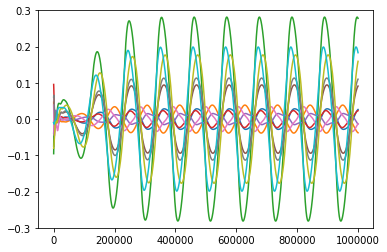

In [78]:
import os
fig = plt.figure()
for i in range(10):
    plt.plot(sim.mons['rnn.x'][:,i])
plt.ylim([-0.3, 0.3])
figs_dir = '/Users/omarschall/daily_reports/report_2023-03-10_MFT_development/figs'
fig_name = 'smaller_norm_x_init_2.pdf'
#fig.savefig(os.path.join(figs_dir, fig_name), format='pdf')